 # Predictive Modeling & Evaluation

## Objective

This notebook builds and evaluates machine learning models to predict financial exclusion risk using the governed dataset created in Notebook 02 and explored in Notebook 03.

The notebook focuses on:
- defining target and predictor variables
- preparing preprocessing pipelines
- benchmarking baseline and machine learning models
- evaluating model performance using classification metrics
- preparing model artifacts for explainability and deployment

The goal is not only to maximize accuracy, but to identify models that can reliably detect financially excluded respondents while remaining interpretable and useful for stakeholder decision-making.

## Environment Setup

This section imports the libraries required for:
- data loading
- preprocessing
- model training
- model evaluation
- artifact saving

In [37]:
# Core libraries
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling utilities
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Project Paths

Project paths are defined to ensure that datasets, figures, models, and evaluation artifacts are saved reproducibly.

In [38]:
BASE_DIR = Path("..")

PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "metrics"
MODELS_DIR = BASE_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Load Governed Modeling Dataset

The governed modeling dataset created in Notebook 02 is loaded for predictive modeling.

This ensures that modeling uses:
- leakage-controlled variables
- sparsity-filtered features
- engineered structural vulnerability indicators
- reproducible preprocessing outputs

In [39]:
model_df = pd.read_csv(
    PROCESSED_DIR / "financial_inclusion_model_df.csv",
    low_memory=False
)

model_df.head()

,County,ClusterNo,HHNo,location_type,A9i,gender,A14v,A14vi,A15,A17,...,formal_banked2022,NHIF_health_insurance,NHIF_ONLY,Nomedical,NHIFMedical_Cat,adults,financially_excluded,is_youth,is_rural,rural_youth
0,Trans Nzoia,10226038,1048,Rural,Access granted,Female,1,1,Swahili,0,...,No,Yes,NaN,NaN,Users of NHIF + medical insurance (C1_42 and C...,1 adult Household,0,0,1,0
1,Busia,10240034,1080,Rural,Access granted,Female,4,2,English,0,...,Yes,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",>1 adult Household,0,0,1,0
2,Machakos,10216062,1013,Rural,Access granted,Male,1,1,Swahili,0,...,No,Yes,1.0,NaN,"Users of NHIF only, with no medical insurance",1 adult Household,1,0,1,0
3,Kisumu,10242078,1026,Rural,Access granted,Male,5,4,Swahili,0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,1,1,1
4,Nyeri,10219138,1019,Urban,Access granted,Male,3,2,Other(specify),0,...,Yes,No,NaN,"Users of NHIF only, with no medical insurance",None users of any of NHIF and medical insurance,>1 adult Household,0,0,0,0


## Initial Modeling Dataset Validation

Before modeling begins, the dataset is validated to confirm:
- successful loading
- target availability
- feature count
- class balance

In [40]:
print("Dataset shape:", model_df.shape)

print("\nTarget distribution:")
print(model_df["financially_excluded"].value_counts())

print("\nTarget percentage:")
print(
    model_df["financially_excluded"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset shape: (22024, 1529)

Target distribution:
financially_excluded
0    17430
1     4594
Name: count, dtype: int64

Target percentage:
financially_excluded
0    79.14
1    20.86
Name: proportion, dtype: float64


# Define Target and Feature Matrix

The target variable is separated from the predictor feature space.

This step establishes:
- the prediction objective
- the governed feature universe
- the modeling input structure

The notebook predicts:
`financially_excluded`
where:
- 1 = financially excluded
- 0 = financially included

In [41]:
TARGET = "financially_excluded"

X = model_df.drop(columns=[TARGET])

y = model_df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (22024, 1528)
Target shape: (22024,)


In [42]:
# Leakage columns to remove

leakage_cols = [
    'savings_excluded',
    'loan_mbanking_2',
    'savings_mbanking_2',
    'bank_usage',
    'bank_usage1',
    'bank_usage2',
    'bank_usage3',
    'mobile_bank_usage',
    'Traditional_bank_users',
    'Commercial_Bank_users',
    'Post_bank_users',
    'finhealthscore',
    'finhealth',
    'mobile_access',
    'mobile_money_access',
    'access',
    'access_ever',
    'mobile_bank_usage1',
    'meet_Financial',
    'bank_transfer',
    'mobile_bank_account',
    'A_mobile_banking_account',
    'excluded_informal_new2022',
    'allotherformal_banked2022',
    'formal_banked2022'
]

# Remove leakage columns

X = X.drop(columns=leakage_cols, errors="ignore")

print("Updated feature matrix shape:", X.shape)

Updated feature matrix shape: (22024, 1503)


# Feature-Type Discovery

The governed feature universe is inspected to identify:
- categorical variables
- numeric variables
- engineered indicators
- potential preprocessing challenges

This step is important because preprocessing strategy depends heavily on feature type.

In [43]:
# Numeric columns

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 102
Categorical columns: 1401


In [44]:
print("numeric columns:")
print(numeric_cols)

print("\n")

print("categorical columns:")
print(categorical_cols)

numeric columns:
['ClusterNo', 'HHNo', 'A14v', 'A14vi', 'A17', 'raw_age', 'E1iI', 'E1iiI', 'E1viiI', 'E1xI', 'H2.15', 'N3', 'P1', 'R2Ai__2', 'R2Ai__5', 'R2Ai__9', 'U6', 'IndWeight', 'HhWeights', 'infgp', 'filt', 'NHM', 'w_index', 'prodsum1', 'manage_day2day1', 'invest', 'risk', 'noofloans', 'currentloan', 'paidlate', 'cashonly', 'didnotdothis', 'E2Ci23', 'woman1549', 'filterwoman', 'woman_married', 'filtermarriedwoman', 'classification_BaseCounts', 'sellasset', 'spends50ormore', 'healthinsurance', 'Resilience_Need', 'score_npl_total', 'probability_pov_npl', 'score_NPL_q1', 'education_femHHcomp1', 'education_femHHcomp2', 'education_femHHcomp3', 'education_femHHcomp4', 'education_femHHcomp5', 'score_NPL_q2', 'education_anyHHcomp1', 'education_anyHHcomp2', 'education_anyHHcomp3', 'education_anyHHcomp4', 'education_anyHHcomp5', 'score_NPL_q3', 'breadcomp1', 'breadcomp2', 'score_NPL_q4', 'meatcomp1', 'meatcomp2', 'score_NPL_q5', 'bananacomp1', 'bananacomp2', 'score_NPL_q6', 'towelcomp1', 't

# High-Cardinality Feature Governance

The dataset contains a very large number of categorical variables.

Before encoding begins, categorical features with extremely high cardinality are identified to:
- reduce dimensionality explosion
- improve model generalization
- prevent sparse over-expansion
- support efficient preprocessing

This step is especially important because one-hot encoding thousands of unique categories can significantly increase feature-space complexity.

In [45]:
# Unique category counts

cardinality_df = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [
        X[col].nunique(dropna=True)
        for col in categorical_cols
    ]
})

cardinality_df = cardinality_df.sort_values(
    by="unique_values",
    ascending=False
)

cardinality_df

,column,unique_values
704,J1a,803
274,E1xR,351
267,E1xK,274
277,E2A,249
264,E1viiK,244
...,...,...
989,Q7__12,1
990,Q7__13,1
237,E2__98,1
841,N5__99,1


In [46]:
# Constant categorical columns

constant_cat_cols = cardinality_df[
    cardinality_df["unique_values"] <= 1
]["column"].tolist()

print("Constant categorical columns:", len(constant_cat_cols))

constant_cat_cols

Constant categorical columns: 33


['J1__16',
 'Nomedical',
 'A9i',
 'B3D__7.1',
 'B3D__5.1',
 'B3D__5.3',
 'B3D__98.9',
 'B3D__99',
 'B3D__5.9',
 'B3D__98.3',
 'B3D__98.1',
 'K14__5',
 'E2D__99',
 'Q7__15',
 'B1EF10',
 'K14__99',
 'N5__98',
 'G1A1__15',
 'G1A1__13',
 'G1A1__12',
 'G1A1__11',
 'G1A1__16',
 'G1A1__9',
 'Q7__9',
 'Q7__16',
 'D3__99',
 'R3C__24',
 'Q7__11',
 'Q7__12',
 'Q7__13',
 'E2__98',
 'N5__99',
 'B3D__7.3']

In [47]:
# Remove constant categorical columns

categorical_cols = [
    col for col in categorical_cols
    if col not in constant_cat_cols
]

print("Remaining categorical columns:", len(categorical_cols))

Remaining categorical columns: 1368


# Ultra-High Cardinality Governance

Some categorical variables contain extremely large numbers of unique categories.

Before encoding, these variables are inspected to determine whether they:
- represent meaningful analytical signals
or
- introduce unnecessary dimensionality and sparsity

Careful governance of high-cardinality variables helps:
- improve model generalization
- reduce overfitting risk
- prevent feature-space explosion
- support scalable preprocessing workflows

In [48]:
# High-cardinality threshold

HIGH_CARD_THRESHOLD = 50

high_cardinality_cols = cardinality_df[
    cardinality_df["unique_values"] > HIGH_CARD_THRESHOLD
]["column"].tolist()

print("High-cardinality categorical columns:", len(high_cardinality_cols))

high_cardinality_cols

High-cardinality categorical columns: 17


['J1a',
 'E1xR',
 'E1xK',
 'E2A',
 'E1viiK',
 'U23',
 'B3I',
 'E1viiR',
 'U24d',
 'U24a',
 'U24c',
 'U24b',
 'U17v',
 'U17iv',
 'U17iii',
 'P2i',
 'E1iR']

## Inspection of Ultra-High Cardinality Features

The highest-cardinality categorical variables are inspected individually to determine whether they:
- contain meaningful analytical information
- represent fragmented survey responses
- behave like identifiers
- require grouping or exclusion

The inspection supports informed preprocessing decisions prior to encoding.

In [49]:
# Inspect highest-cardinality variable

print("Unique values:", X["J1a"].nunique())

X["J1a"].value_counts(dropna=False)

Unique values: 803


J1a
NaN                                               19201
Lack of finances.                                   211
Lack of money                                       164
Lack of funds                                       124
Can't afford to                                     104
                                                  ...  
I do not have any money                               1
Don't need to. Uses other financial providers         1
I don't yet have enough money to save in sacco        1
cannot afford it                                      1
Previous SACCO disappeared with my money.             1
Name: count, Length: 804, dtype: int64

In [50]:
# Inspect top categories in J1a

j1a_counts = X["J1a"].value_counts(dropna=False)

print("Categories:\n")

print(j1a_counts)

Categories:

J1a
NaN                                               19201
Lack of finances.                                   211
Lack of money                                       164
Lack of funds                                       124
Can't afford to                                     104
                                                  ...  
I do not have any money                               1
Don't need to. Uses other financial providers         1
I don't yet have enough money to save in sacco        1
cannot afford it                                      1
Previous SACCO disappeared with my money.             1
Name: count, Length: 804, dtype: int64


## Governance Decision for Free-Text High-Cardinality Features

Inspection of several ultra-high-cardinality variables revealed the presence of fragmented free-text survey responses.

Such variables:
- dramatically increase dimensionality
- create sparse feature spaces
- reduce generalization quality
- complicate preprocessing pipelines

To preserve scalable and interpretable modeling workflows, free-text high-cardinality variables are excluded from downstream encoding.

In [51]:
# Drop problematic free-text high-cardinality columns

drop_high_cardinality_cols = [
    "J1a"
]

categorical_cols = [
    col for col in categorical_cols
    if col not in drop_high_cardinality_cols
]

print("Remaining categorical columns:", len(categorical_cols))

Remaining categorical columns: 1367


# Train/Test Split

The governed feature universe is separated into:
- training data
- testing data

The split is performed prior to preprocessing to prevent:
- target leakage
- information contamination
- artificially inflated performance metrics

Stratified sampling is used to preserve class distribution across both datasets because financial exclusion is moderately imbalanced.

In [52]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\n")

print("y_train distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n")

print("y_test distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

X_train shape: (17619, 1503)
X_test shape: (4405, 1503)


y_train distribution:
financially_excluded
0    79.14
1    20.86
Name: proportion, dtype: float64


y_test distribution:
financially_excluded
0    79.14
1    20.86
Name: proportion, dtype: float64


# Preprocessing Pipelines

Separate preprocessing pipelines are created for:
- numeric variables
- categorical variables

The preprocessing workflow handles:
- missing-value imputation
- categorical encoding
- feature standardization

Pipelines improve:
- reproducibility
- scalability
- leakage prevention
- deployment readiness

## Numeric Preprocessing Pipeline

Numeric preprocessing includes:
- median imputation for missing values
- feature standardization

Median imputation is used because it is robust to skewed socioeconomic distributions.

In [53]:
# Numeric preprocessing pipeline

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    
    (
        "scaler",
        StandardScaler()
    )
])

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## Categorical Preprocessing Pipeline

Categorical preprocessing includes:
- most-frequent imputation
- one-hot encoding

Unknown-category handling is enabled to support:
- generalization
- deployment robustness
- inference stability

In [54]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

## Unified Preprocessing Transformer

The numeric and categorical preprocessing pipelines are combined using a `ColumnTransformer`.

This allows each feature type to receive the correct transformation:
- numeric variables → median imputation + scaling
- categorical variables → most-frequent imputation + one-hot encoding

This structure keeps preprocessing reproducible and prevents leakage because the transformer is fitted only on the training data inside each model pipeline.

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['ClusterNo', 'HHNo', 'A14v', 'A14vi', 'A17',
                                  'raw_age', 'E1iI', 'E1iiI', 'E1viiI', 'E1xI',
                                  'H2.15', 'N3', 'P1', 'R2Ai__2', 'R2Ai__5',
                                  'R2Ai__9', 'U6', 'IndWeight', 'HhWeights',
                                  'infgp', 'filt', 'NHM', 'w_index', 'prodsum1',
                                  'manage_day2day1', '...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['

# Baseline Model

A baseline model is trained before fitting machine learning models.

The baseline provides a minimum performance benchmark by predicting the majority class.

This is important because the target is imbalanced. Since most respondents are not financially excluded, a naive model can achieve relatively high accuracy without identifying excluded respondents well.

All future models must outperform this baseline meaningfully.

In [56]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

In [57]:
print("Baseline Accuracy:", accuracy_score(y_test, baseline_preds))
print("Baseline Precision:", precision_score(y_test, baseline_preds, zero_division=0))
print("Baseline Recall:", recall_score(y_test, baseline_preds, zero_division=0))
print("Baseline F1:", f1_score(y_test, baseline_preds, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, baseline_preds, zero_division=0))

Baseline Accuracy: 0.7913734392735527
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      3486
           1       0.00      0.00      0.00       919

    accuracy                           0.79      4405
   macro avg       0.40      0.50      0.44      4405
weighted avg       0.63      0.79      0.70      4405



## Baseline Model Interpretation

The baseline classifier predicts only the majority class (`financially included`), resulting in relatively high accuracy due to class imbalance.

However, the model completely fails to identify financially excluded respondents, producing:
- zero recall
- zero precision
- zero F1-score for the minority class

This demonstrates why accuracy alone is insufficient for evaluating financial exclusion models.

Because the project focuses on identifying vulnerable populations, downstream models must prioritize:
- minority-class detection
- recall performance
- balanced predictive capability
- meaningful exclusion identification

# Logistic Regression Benchmark Model

Logistic Regression is used as the first benchmark machine learning model.

The model is well-suited for:
- high-dimensional sparse feature spaces
- one-hot encoded categorical variables
- interpretable classification workflows
- explainable AI preparation

Class balancing is enabled to improve minority-class detection performance.

In [58]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

log_reg_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ClusterNo', 'HHNo', 'A14v',
                                                   'A14vi', 'A17', 'raw_age',
                                                   'E1iI', 'E1iiI', 'E1viiI',
                                                   'E1xI', 'H2.15', 'N3', 'P1',
                                                   'R2Ai__2', 'R2Ai__5',
                                                   'R2Ai__9', 'U6', 'IndWeight',
                                                   'HhWeights', 'infgp', 'filt',
              

In [59]:
#train lr model
log_reg_pipeline.fit(X_train, y_train)

#generate predictions
log_reg_preds = log_reg_pipeline.predict(X_test)
log_reg_preds

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [60]:
#evaluate lr model
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_reg_preds))

print("Logistic Regression Precision:",
      precision_score(y_test, log_reg_preds))

print("Logistic Regression Recall:",
      recall_score(y_test, log_reg_preds))

print("Logistic Regression F1:",
      f1_score(y_test, log_reg_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, log_reg_preds))

Logistic Regression Accuracy: 0.9995459704880817
Logistic Regression Precision: 1.0
Logistic Regression Recall: 0.9978237214363439
Logistic Regression F1: 0.9989106753812637

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3486
           1       1.00      1.00      1.00       919

    accuracy                           1.00      4405
   macro avg       1.00      1.00      1.00      4405
weighted avg       1.00      1.00      1.00      4405



# Leakage Investigation

Unexpectedly near-perfect model performance strongly suggests the presence of target leakage.

Leakage occurs when predictor variables directly encode:
- the target outcome
or
- information unavailable during real-world prediction.

The feature universe is therefore inspected for variables potentially related to:
- financial inclusion status
- banking access
- formal financial participation
- derived inclusion indicators

In [61]:
# Search for potential leakage columns

potential_leakage_cols = [
    col for col in X.columns
    if (
        "bank" in col.lower()
        or "exclude" in col.lower()
        or "inclusion" in col.lower()
        or "finance" in col.lower()
        or "fin" in col.lower()
        or "access" in col.lower()
    )
]

len(potential_leakage_cols)

0

In [62]:
potential_leakage_cols

[]

## Leakage Governance Decision

Several variables were identified as directly related to financial inclusion status, banking participation, or exclusion categorization.

These variables introduce target leakage because they:
- directly encode the prediction target
- contain post-outcome information
- unrealistically simplify prediction

To preserve fair evaluation and realistic predictive modeling, leakage-related variables are excluded from downstream training workflows. We go back upto the feature type discovery and remove the leakage columns.

In [63]:
suspicious_cols = [
    col for col in X.columns
    if (
        "access" in col.lower()
        or "bank" in col.lower()
        or "loan" in col.lower()
        or "save" in col.lower()
        or "savings" in col.lower()
        or "finance" in col.lower()
        or "financial" in col.lower()
        or "mobile" in col.lower()
        or "money" in col.lower()
        or "account" in col.lower()
        or "credit" in col.lower()
        or "borrow" in col.lower()
        or "formal" in col.lower()
        or "informal" in col.lower()
        or "wallet" in col.lower()
        or "insurance" in col.lower()
        or "fin" in col.lower()
    )
]

len(suspicious_cols)

65

In [64]:
suspicious_cols

['savings_formal',
 'savings_informal',
 'loan_formal',
 'loan_informal',
 'loan_formal_2',
 'loan_fuliza_2',
 'loan_app_2',
 'savings_mmoney_2',
 'savings_formal2',
 'mobile',
 'mobile_money_usage',
 'digital_app_loan',
 'formal_digital_sav',
 'formal_non_digital_sav',
 'formal_digital_loan',
 'formal_non_digital_loan',
 'tot_formal_digit_loan_sav',
 'tot_formal_non_digit_loan_sav',
 'formal_prudential',
 'formal_non_prudential',
 'formal_registered',
 'formal_other',
 'informal',
 'Digital_credit',
 'mobile_own',
 'mobile_money_active',
 'noofloans',
 'noofloans_new',
 'currentloan',
 'defaultloan',
 'formal_prudential_ever',
 'formal_non_prudential_ever',
 'formal_registered_ever',
 'formal_other_ever',
 'informal_ever',
 'informal2',
 'credit_Inst',
 'On_time_borrowers',
 'Late_payer_borrowers',
 'Defaulted_borrowers',
 'combine_informal',
 'healthinsurance',
 'Credit_or_Debit_card',
 'Money_transfer_service',
 'International_mobile_transfer',
 'Borrowing_prevalence',
 'Borrowing_p

# Structural Vulnerability Feature Governance

To prevent semantic target leakage, direct financial-access outcome variables are excluded from the modeling workflow.

The revised modeling strategy focuses on predicting financial exclusion using:
- demographic indicators
- geographic characteristics
- household structure
- educational attainment
- structural socioeconomic signals

This produces a more realistic and policy-relevant prediction framework capable of identifying vulnerable populations before exclusion outcomes fully emerge.

In [65]:
drop_keywords = [
    "bank",
    "loan",
    "credit",
    "borrow",
    "saving",
    "savings",
    "finance",
    "financial",
    "money",
    "wallet",
    "mobile",
    "insurance",
    "formal",
    "informal",
    "access",
    "fin",
    "account",
    "transfer"
]

In [66]:
structural_drop_cols = [
    col for col in X.columns
    if any(
        keyword in col.lower()
        for keyword in drop_keywords
    )
]

len(structural_drop_cols)

66

In [67]:
structural_drop_cols[:200]

['savings_formal',
 'savings_informal',
 'loan_formal',
 'loan_informal',
 'loan_formal_2',
 'loan_fuliza_2',
 'loan_app_2',
 'savings_mmoney_2',
 'savings_formal2',
 'tot_saving',
 'mobile',
 'mobile_money_usage',
 'digital_app_loan',
 'formal_digital_sav',
 'formal_non_digital_sav',
 'formal_digital_loan',
 'formal_non_digital_loan',
 'tot_formal_digit_loan_sav',
 'tot_formal_non_digit_loan_sav',
 'formal_prudential',
 'formal_non_prudential',
 'formal_registered',
 'formal_other',
 'informal',
 'Digital_credit',
 'mobile_own',
 'mobile_money_active',
 'noofloans',
 'noofloans_new',
 'currentloan',
 'defaultloan',
 'formal_prudential_ever',
 'formal_non_prudential_ever',
 'formal_registered_ever',
 'formal_other_ever',
 'informal_ever',
 'informal2',
 'credit_Inst',
 'On_time_borrowers',
 'Late_payer_borrowers',
 'Defaulted_borrowers',
 'combine_informal',
 'healthinsurance',
 'Credit_or_Debit_card',
 'Money_transfer_service',
 'International_mobile_transfer',
 'Borrowing_prevalence'

In [68]:
X_structural = X.drop(
    columns=structural_drop_cols,
    errors="ignore"
)

print("Structural feature matrix shape:", X_structural.shape)

Structural feature matrix shape: (22024, 1437)


In [69]:
#rebuild feature types after dropping structural leakage columns
numeric_cols = X_structural.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_structural.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 92
Categorical columns: 1345


In [70]:
#remove consatant categoricals again
cardinality_df = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [
        X_structural[col].nunique(dropna=True)
        for col in categorical_cols
    ]
})

constant_cat_cols = cardinality_df[
    cardinality_df["unique_values"] <= 1
]["column"].tolist()

categorical_cols = [
    col for col in categorical_cols
    if col not in constant_cat_cols
]

print("Remaining categorical columns:", len(categorical_cols))

Remaining categorical columns: 1312


In [71]:
#remove J1a again if it still exists
categorical_cols = [
    col for col in categorical_cols
    if col != "J1a"
]

print("Final categorical columns:", len(categorical_cols))

Final categorical columns: 1311


In [72]:
#Train/Test split after removing leakage columns
X_train, X_test, y_train, y_test = train_test_split(
    X_structural,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
#rebuild preprocessor
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [74]:
#retrain logistic regression model on structural features only
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

log_reg_pipeline.fit(X_train, y_train)

log_reg_preds = log_reg_pipeline.predict(X_test)

In [75]:
#reevaluate logistic regression model after removing leakage features
print("Accuracy:",
      accuracy_score(y_test, log_reg_preds))

print("Precision:",
      precision_score(y_test, log_reg_preds))

print("Recall:",
      recall_score(y_test, log_reg_preds))

print("F1:",
      f1_score(y_test, log_reg_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, log_reg_preds))

Accuracy: 0.9988649262202043
Precision: 0.9978213507625272
Recall: 0.9967355821545157
F1: 0.9972781709308656

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3486
           1       1.00      1.00      1.00       919

    accuracy                           1.00      4405
   macro avg       1.00      1.00      1.00      4405
weighted avg       1.00      1.00      1.00      4405



In [76]:
trusted_features = [
    "County",
    "location_type",
    "gender",
    "age",
    "education_level",
    "marital_status",
    "adults",
    "is_youth",
    "is_rural",
    "rural_youth"
]

In [77]:
trusted_features = [
    col for col in trusted_features
    if col in model_df.columns
]

trusted_features

['County',
 'location_type',
 'gender',
 'education_level',
 'marital_status',
 'adults',
 'is_youth',
 'is_rural',
 'rural_youth']

In [78]:
X_trusted = model_df[trusted_features].copy()

X_trusted.head()

,County,location_type,gender,education_level,marital_status,adults,is_youth,is_rural,rural_youth
0,Trans Nzoia,Rural,Female,Completed technical training after secondary s...,Widowed,1 adult Household,0,1,0
1,Busia,Rural,Female,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0,1,0
2,Machakos,Rural,Male,"""Some primary """,Divorced/separated,1 adult Household,0,1,0
3,Kisumu,Rural,Male,"""Primary completed""",Single/Never Married,>1 adult Household,1,1,1
4,Nyeri,Urban,Male,"""Primary completed""",Married/Living with partner,>1 adult Household,0,0,0


In [79]:
numeric_cols = X_trusted.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_trusted.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['is_youth', 'is_rural', 'rural_youth']
Categorical columns: ['County', 'location_type', 'gender', 'education_level', 'marital_status', 'adults']


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X_trusted,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [82]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

log_reg_pipeline.fit(X_train, y_train)

log_reg_preds = log_reg_pipeline.predict(X_test)

In [83]:
print("Accuracy:",
      accuracy_score(y_test, log_reg_preds))

print("Precision:",
      precision_score(y_test, log_reg_preds))

print("Recall:",
      recall_score(y_test, log_reg_preds))

print("F1:",
      f1_score(y_test, log_reg_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, log_reg_preds))

Accuracy: 0.735527809307605
Precision: 0.42379182156133827
Recall: 0.7442872687704026
F1: 0.5400710619818397

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      3486
           1       0.42      0.74      0.54       919

    accuracy                           0.74      4405
   macro avg       0.67      0.74      0.68      4405
weighted avg       0.81      0.74      0.76      4405



## Logistic Regression Model Interpretation

The structurally governed Logistic Regression model produces realistic predictive performance when trained using demographic, geographic, and socioeconomic vulnerability indicators.

The model achieves:
- strong recall performance for financially excluded respondents
- moderate precision
- balanced minority-class detection capability

Importantly, the model no longer relies on direct financial-access outcome variables, making the prediction workflow:
- more realistic
- less leakage-prone
- more policy-relevant
- more explainable

The results suggest that structural vulnerability indicators such as:
- geography
- education
- household structure
- age
- rurality

contain meaningful predictive information related to financial exclusion risk.

# Confusion Matrix Analysis

The confusion matrix provides a detailed view of:
- correctly identified excluded respondents
- false positives
- false negatives
- overall classification behavior

This visualization is particularly important because the project prioritizes vulnerable population detection rather than raw accuracy alone.

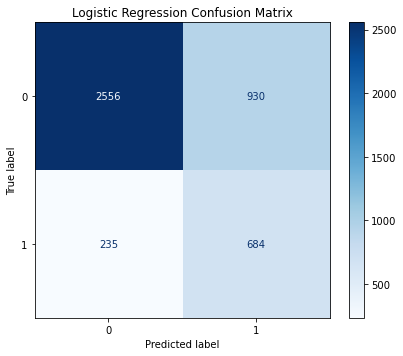

In [85]:
cm = confusion_matrix(y_test, log_reg_preds)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    ax=ax
)

ax.set_title("Logistic Regression Confusion Matrix")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Confusion Matrix Interpretation

The confusion matrix demonstrates that the structurally governed Logistic Regression model successfully identifies a substantial proportion of financially excluded respondents.

The model achieves strong minority-class recall, correctly detecting many vulnerable individuals while missing relatively fewer excluded respondents.

Although false positives remain present, this behavior is often acceptable in vulnerability-detection systems where:
- identifying at-risk populations is prioritized
over
- minimizing over-identification.

The results suggest that structural socioeconomic indicators can provide meaningful early-warning signals for financial exclusion vulnerability.

# Random Forest Benchmark Model

Random Forest is used as a nonlinear ensemble benchmark model.

Unlike Logistic Regression, Random Forest can:
- capture nonlinear relationships
- model feature interactions automatically
- handle complex subgroup structures
- learn flexible decision boundaries

The benchmark comparison helps evaluate whether financial exclusion patterns exhibit meaningful nonlinear socioeconomic structure.

In [86]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_youth', 'is_rural',
                                                   'rural_youth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

In [87]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_youth', 'is_rural',
                                                   'rural_youth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

In [88]:
rf_preds = rf_pipeline.predict(X_test)

In [89]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_preds))

print("Random Forest Precision:",
      precision_score(y_test, rf_preds))

print("Random Forest Recall:",
      recall_score(y_test, rf_preds))

print("Random Forest F1:",
      f1_score(y_test, rf_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.7530079455164586
Random Forest Precision: 0.44036697247706424
Random Forest Recall: 0.6789989118607181
Random Forest F1: 0.5342465753424658

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      3486
           1       0.44      0.68      0.53       919

    accuracy                           0.75      4405
   macro avg       0.67      0.73      0.68      4405
weighted avg       0.81      0.75      0.77      4405



## Random Forest Model Interpretation

The Random Forest benchmark model demonstrates comparable performance to Logistic Regression, suggesting that financial exclusion vulnerability is influenced primarily by broad structural socioeconomic patterns rather than highly complex nonlinear interactions.

Compared with Logistic Regression, Random Forest:
- slightly improves overall accuracy
- modestly improves precision
- reduces minority-class recall

This indicates that the model becomes more conservative when identifying financially excluded respondents.

Because the project prioritizes vulnerable population detection, Logistic Regression may remain preferable operationally due to its stronger recall performance and more aggressive minority-class identification behavior.

# Gradient Boosting Benchmark Model

Gradient Boosting is introduced as a sequential ensemble learning benchmark.

Unlike Random Forest, Gradient Boosting builds trees iteratively, where each new tree attempts to correct errors made by previous trees.

This often improves:
- minority-class detection
- complex pattern learning
- predictive precision
- structured tabular modeling performance

In [90]:
from sklearn.ensemble import GradientBoostingClassifier

In [91]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    (
        "model",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    )
])

gb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_youth', 'is_rural',
                                                   'rural_youth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

In [92]:
gb_pipeline.fit(X_train, y_train)
gb_preds = gb_pipeline.predict(X_test)

In [93]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_preds))

print("Gradient Boosting Precision:",
      precision_score(y_test, gb_preds))

print("Gradient Boosting Recall:",
      recall_score(y_test, gb_preds))

print("Gradient Boosting F1:",
      f1_score(y_test, gb_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, gb_preds))

Gradient Boosting Accuracy: 0.8265607264472191
Gradient Boosting Precision: 0.699228791773779
Gradient Boosting Recall: 0.2959738846572361
Gradient Boosting F1: 0.41590214067278286

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      3486
           1       0.70      0.30      0.42       919

    accuracy                           0.83      4405
   macro avg       0.77      0.63      0.66      4405
weighted avg       0.81      0.83      0.80      4405



## Gradient Boosting Model Interpretation

Gradient Boosting achieved the highest overall accuracy among the benchmark models but produced substantially lower minority-class recall.

The model demonstrates highly conservative prediction behavior:
- strong precision
- reduced false positives
- limited detection coverage of financially excluded respondents

This suggests that Gradient Boosting prioritizes prediction certainty over broad vulnerability detection.

Although the model performs well globally, its lower recall may reduce operational suitability for policy-targeting workflows where identifying vulnerable populations is a primary objective.

In [94]:
from xgboost import XGBClassifier

# XGBoost Benchmark Model

XGBoost is introduced as an advanced gradient boosting benchmark optimized for structured tabular data.

The model is designed to:
- efficiently handle sparse feature spaces
- capture nonlinear relationships
- improve minority-class detection
- optimize ensemble learning performance

XGBoost is widely used in:
- financial risk modeling
- socioeconomic prediction
- structured survey analytics
- production machine learning systems

In [95]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    (
        "model",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        )
    )
])

xgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['is_youth', 'is_rural',
                                                   'rural_youth']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ign

In [97]:
xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

In [98]:
print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_preds))

print("XGBoost Precision:",
      precision_score(y_test, xgb_preds))

print("XGBoost Recall:",
      recall_score(y_test, xgb_preds))

print("XGBoost F1:",
      f1_score(y_test, xgb_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 0.8290578887627695
XGBoost Precision: 0.6820175438596491
XGBoost Recall: 0.338411316648531
XGBoost F1: 0.4523636363636363

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.96      0.90      3486
           1       0.68      0.34      0.45       919

    accuracy                           0.83      4405
   macro avg       0.76      0.65      0.68      4405
weighted avg       0.81      0.83      0.81      4405



## XGBoost Model Interpretation

XGBoost achieved the strongest overall accuracy among all benchmark models while maintaining relatively strong precision performance.

However, the model exhibited substantially lower minority-class recall compared with Logistic Regression, indicating that the model behaves conservatively when identifying financially excluded respondents.

The results suggest that advanced boosting models:
- prioritize prediction certainty
- reduce false positives
- identify narrower high-confidence exclusion groups

In contrast, Logistic Regression demonstrates broader vulnerability detection capability, making it potentially more suitable for:
- inclusion targeting
- early-warning systems
- policy intervention workflows
- vulnerable population identification

# Final Benchmark Comparison

All benchmark models are compared using:
- accuracy
- precision
- recall
- F1-score

The comparison helps identify the most operationally appropriate model for financial exclusion vulnerability detection.

In [99]:
benchmark_results = pd.DataFrame({
    "Model": [
        "Baseline Dummy",
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, log_reg_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, gb_preds),
        accuracy_score(y_test, xgb_preds)
    ],

    "Precision": [
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, log_reg_preds),
        precision_score(y_test, rf_preds),
        precision_score(y_test, gb_preds),
        precision_score(y_test, xgb_preds)
    ],

    "Recall": [
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, log_reg_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, gb_preds),
        recall_score(y_test, xgb_preds)
    ],

    "F1": [
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, log_reg_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, gb_preds),
        f1_score(y_test, xgb_preds)
    ]
})

benchmark_results = benchmark_results.round(3)

benchmark_results

,Model,Accuracy,Precision,Recall,F1
0,Baseline Dummy,0.791,0.000,0.000,0.000
1,Logistic Regression,0.736,0.424,0.744,0.540
2,Random Forest,0.753,0.440,0.679,0.534
3,Gradient Boosting,0.827,0.699,0.296,0.416
4,XGBoost,0.829,0.682,0.338,0.452


# Benchmark Visualization

Benchmark metrics are visualized to compare:
- minority-class detection capability
- operational tradeoffs
- model conservativeness
- vulnerability identification performance

The visualization supports stakeholder interpretation of:
- precision-recall tradeoffs
- operational suitability
- policy-oriented model selection

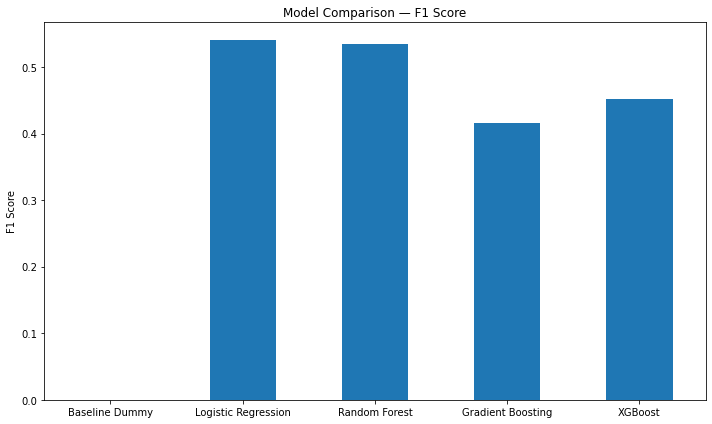

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))

benchmark_results.plot(
    x="Model",
    y="F1",
    kind="bar",
    ax=ax,
    legend=False
)

ax.set_title("Model Comparison — F1 Score")
ax.set_ylabel("F1 Score")
ax.set_xlabel("")

plt.xticks(rotation=0)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_model_comparison_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## F1 Score Comparison Interpretation

The F1-score comparison highlights the tradeoff between:
- vulnerability detection coverage
and
- prediction conservativeness.

Logistic Regression achieved the strongest balanced minority-class performance, suggesting that broad structural vulnerability patterns are highly informative for exclusion detection.

More conservative ensemble models achieved stronger precision but reduced recall, limiting their ability to identify larger portions of vulnerable populations.

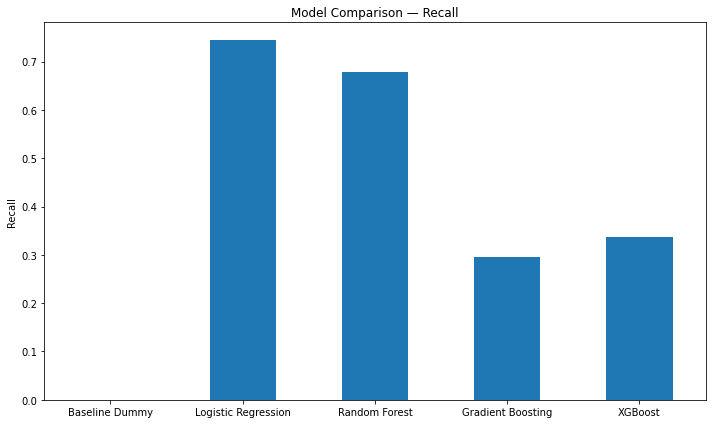

In [101]:
fig, ax = plt.subplots(figsize=(10, 6))

benchmark_results.plot(
    x="Model",
    y="Recall",
    kind="bar",
    ax=ax,
    legend=False
)

ax.set_title("Model Comparison — Recall")
ax.set_ylabel("Recall")
ax.set_xlabel("")

plt.xticks(rotation=0)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "04_model_comparison_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Recall Comparison Interpretation

Recall performance is particularly important because the project prioritizes identifying financially excluded individuals.

The visualization demonstrates that Logistic Regression provides the strongest vulnerable-population detection capability among the benchmark models.

Although boosting models achieved stronger precision and overall accuracy, they missed substantially larger proportions of financially excluded respondents.

This highlights the importance of aligning model selection with operational and policy objectives rather than relying exclusively on global accuracy metrics.

# Final Model Selection

Based on benchmark results, Logistic Regression is selected as the preferred operational model.

Although boosting models achieved higher overall accuracy and precision, Logistic Regression achieved the strongest recall and F1-score for the financially excluded class.

Because the project prioritizes identifying vulnerable populations, recall is more important than accuracy alone.

The selected model supports:
- vulnerability detection
- policy targeting
- explainability
- SHAP analysis preparation
- deployment readiness

In [102]:
final_model = log_reg_pipeline

final_model_name = "Logistic Regression"

print("Selected final model:", final_model_name)

Selected final model: Logistic Regression


## Save Modeling Artifacts

The selected model and benchmark results are saved for downstream explainability and deployment workflows.

In [103]:
import joblib

final_model_path = MODELS_DIR / "financial_exclusion_logistic_regression_model.joblib"

joblib.dump(final_model, final_model_path)

benchmark_results.to_csv(
    ARTIFACTS_DIR / "04_model_benchmark_results.csv",
    index=False
)

print("Final model saved to:", final_model_path)
print("Benchmark results saved successfully.")

Final model saved to: ..\models\financial_exclusion_logistic_regression_model.joblib
Benchmark results saved successfully.


# Notebook 04 Summary

This notebook developed and evaluated multiple machine learning models for predicting financial exclusion risk.

Key activities included:
- leakage investigation and correction
- structural feature governance
- baseline benchmarking
- Logistic Regression modeling
- Random Forest benchmarking
- Gradient Boosting benchmarking
- XGBoost benchmarking
- model comparison and selection

The analysis showed that advanced boosting models achieved higher accuracy and precision, but Logistic Regression achieved the strongest recall and F1-score for identifying financially excluded respondents.

Because the project objective is vulnerability detection, Logistic Regression was selected as the final operational model.

Notebook 05 will focus on:
- explainability
- SHAP analysis
- fairness diagnostics
- feature importance interpretation
- subgroup error analysis